# WORKSHEET - 4

**Department of Computer Science and Engineering**
**2024 CSE BATCH — 23CSE463 : Quantum Computing**

**Name:** Agneay B Nair
**Roll No:** CH.SC.U4CSE24102

**Ex. No:** 4   |   **Date:** 23/07/2026

**Title:** Study of Parameterized Rotation Gates (Rx, Ry, and Rz) Using PennyLane

**Aim:** To design and simulate parameterized quantum circuits using Rotation-X (Rx), Rotation-Y (Ry), and Rotation-Z (Rz) gates in PennyLane, and study their influence on quantum state evolution, measurement probabilities, expectation values, and entanglement in single-qubit and multi-qubit quantum systems.

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

dev1 = qml.device('default.qubit', wires=1)
dev2 = qml.device('default.qubit', wires=2)

print("Setup complete: PennyLane version", qml.__version__)

Setup complete: PennyLane version 0.45.1


### Program 1
Create a single-qubit quantum circuit and apply the Rotation-X (Rx) gate with a rotation angle of π/4. Display the resulting quantum state and visualize the quantum circuit.

theta = pi/4 = 0.7854
Resulting state |psi> = [0.92387953+0.j         0.        -0.38268343j]
0: ──RX(0.79)─┤  State


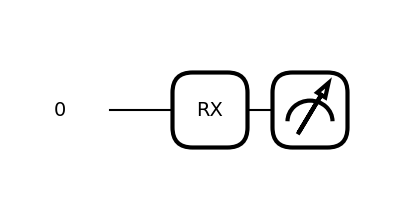

In [2]:
@qml.qnode(dev1)
def prog1(theta):
    qml.RX(theta, wires=0)
    return qml.state()

theta = np.pi/4
state = prog1(theta)
print(f"theta = pi/4 = {theta:.4f}")
print(f"Resulting state |psi> = {state}")
print(qml.draw(prog1)(theta))
qml.draw_mpl(prog1)(theta)
plt.show()

### Program 2
Create a single-qubit quantum circuit and apply the Rotation-Y (Ry) gate with a rotation angle of π/3. Display the resulting quantum state and visualize the quantum circuit.

theta = pi/3 = 1.0472
Resulting state |psi> = [0.8660254+0.j 0.5      +0.j]
0: ──RY(1.05)─┤  State


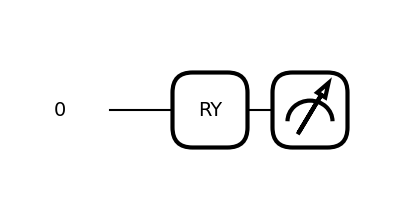

In [3]:
@qml.qnode(dev1)
def prog2(theta):
    qml.RY(theta, wires=0)
    return qml.state()

theta = np.pi/3
state = prog2(theta)
print(f"theta = pi/3 = {theta:.4f}")
print(f"Resulting state |psi> = {state}")
print(qml.draw(prog2)(theta))
qml.draw_mpl(prog2)(theta)
plt.show()

### Program 3
Create a single-qubit quantum circuit and apply the Rotation-Z (Rz) gate with a rotation angle of π/2. Display the resulting quantum state and visualize the quantum circuit.

theta = pi/2 = 1.5708
Resulting state |psi> = [0.70710678-0.70710678j 0.        +0.j        ]
0: ──RZ(1.57)─┤  State


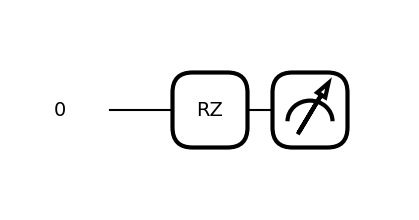

In [4]:
@qml.qnode(dev1)
def prog3(theta):
    qml.RZ(theta, wires=0)
    return qml.state()

theta = np.pi/2
state = prog3(theta)
print(f"theta = pi/2 = {theta:.4f}")
print(f"Resulting state |psi> = {state}")
print(qml.draw(prog3)(theta))
qml.draw_mpl(prog3)(theta)
plt.show()

### Program 4
Design a single-qubit quantum circuit by applying the Rotation-X (Rx) gate followed by the Rotation-Y (Ry) gate. Display the final quantum state and visualize the quantum circuit.

Rx(pi/4) then Ry(pi/3) -> final state = [0.80010315+0.19134172j 0.46193977-0.33141357j]
0: ──RX(0.79)──RY(1.05)─┤  State


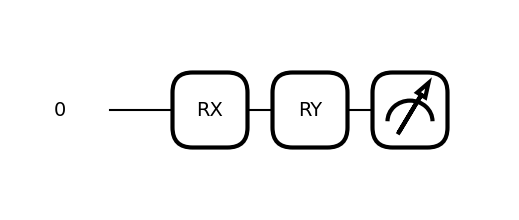

In [5]:
@qml.qnode(dev1)
def prog4(tx, ty):
    qml.RX(tx, wires=0)
    qml.RY(ty, wires=0)
    return qml.state()

tx, ty = np.pi/4, np.pi/3
state = prog4(tx, ty)
print(f"Rx(pi/4) then Ry(pi/3) -> final state = {state}")
print(qml.draw(prog4)(tx, ty))
qml.draw_mpl(prog4)(tx, ty)
plt.show()

### Program 5
Construct a single-qubit quantum circuit by applying the Rotation-X (Rx), Rotation-Y (Ry), and Rotation-Z (Rz) gates sequentially. Display the resulting quantum state and visualize the quantum circuit.

Rx(pi/4) -> Ry(pi/3) -> Rz(pi/2)  final state = [0.70105738-0.43045933j 0.56098553+0.09229596j]
0: ──RX(0.79)──RY(1.05)──RZ(1.57)─┤  State


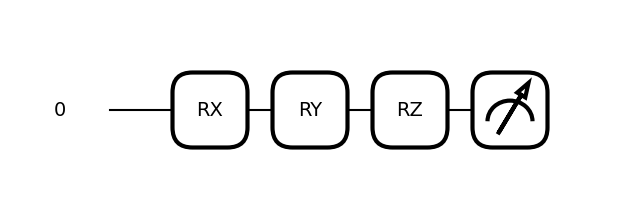

In [6]:
@qml.qnode(dev1)
def prog5(tx, ty, tz):
    qml.RX(tx, wires=0)
    qml.RY(ty, wires=0)
    qml.RZ(tz, wires=0)
    return qml.state()

tx, ty, tz = np.pi/4, np.pi/3, np.pi/2
state = prog5(tx, ty, tz)
print(f"Rx(pi/4) -> Ry(pi/3) -> Rz(pi/2)  final state = {state}")
print(qml.draw(prog5)(tx, ty, tz))
qml.draw_mpl(prog5)(tx, ty, tz)
plt.show()

### Program 6
Create a single-qubit quantum circuit by applying the Rotation-X (Rx), Rotation-Y (Ry), and Rotation-Z (Rz) gates individually using the same rotation angle (π/4). Display the resulting quantum state for each gate and compare their outputs.

In [7]:
theta = np.pi/4

@qml.qnode(dev1)
def prog6_rx(theta):
    qml.RX(theta, wires=0); return qml.state()
@qml.qnode(dev1)
def prog6_ry(theta):
    qml.RY(theta, wires=0); return qml.state()
@qml.qnode(dev1)
def prog6_rz(theta):
    qml.RZ(theta, wires=0); return qml.state()

states6 = {"Rx(pi/4)": prog6_rx(theta), "Ry(pi/4)": prog6_ry(theta), "Rz(pi/4)": prog6_rz(theta)}
for name, s in states6.items():
    print(f"{name}: state = {s}, probabilities = {np.round(np.abs(s)**2,4)}")

print("\nObservation: Rx and Ry both mix |0> and |1> (Rx keeps a complex amplitude, Ry keeps real amplitudes), "
      "while Rz only changes the relative phase and leaves the probabilities unchanged at (1,0).")

Rx(pi/4): state = [0.92387953+0.j         0.        -0.38268343j], probabilities = [0.8536 0.1464]
Ry(pi/4): state = [0.92387953+0.j 0.38268343+0.j], probabilities = [0.8536 0.1464]
Rz(pi/4): state = [0.92387953-0.38268343j 0.        +0.j        ], probabilities = [1. 0.]

Observation: Rx and Ry both mix |0> and |1> (Rx keeps a complex amplitude, Ry keeps real amplitudes), while Rz only changes the relative phase and leaves the probabilities unchanged at (1,0).


### Program 7
Develop a single-qubit quantum circuit that varies the Rotation-Y (Ry) angle from 0 to 2π. Measure the expectation value of the Pauli-Z operator and plot the graph of expectation value versus rotation angle.

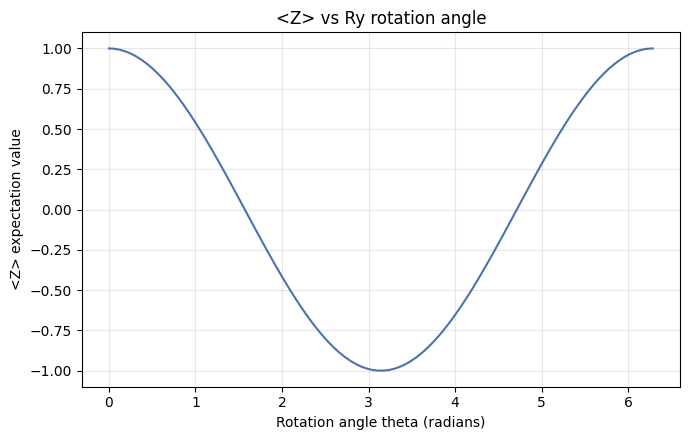

theta=0      -> <Z> = 1.0000
theta=pi/2   -> <Z> = 0.0000
theta=pi     -> <Z> = -1.0000
theta=3pi/2  -> <Z> = -0.0000
theta=2pi    -> <Z> = 1.0000

Observation: <Z> follows cos(theta): starting at +1, dropping to -1 at theta=pi, and returning to +1 at theta=2pi.


In [8]:
@qml.qnode(dev1)
def prog7(theta):
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

angles = np.linspace(0, 2*np.pi, 100)
expvals = [prog7(a) for a in angles]

plt.figure(figsize=(7,4.5))
plt.plot(angles, expvals, color='#4C72B0')
plt.xlabel('Rotation angle theta (radians)')
plt.ylabel('<Z> expectation value')
plt.title('<Z> vs Ry rotation angle')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"theta=0      -> <Z> = {prog7(0):.4f}")
print(f"theta=pi/2   -> <Z> = {prog7(np.pi/2):.4f}")
print(f"theta=pi     -> <Z> = {prog7(np.pi):.4f}")
print(f"theta=3pi/2  -> <Z> = {prog7(3*np.pi/2):.4f}")
print(f"theta=2pi    -> <Z> = {prog7(2*np.pi):.4f}")
print("\nObservation: <Z> follows cos(theta): starting at +1, dropping to -1 at theta=pi, and returning to +1 at theta=2pi.")

### Program 8
Write a PennyLane program to create a single-qubit quantum circuit that applies a Hadamard (H) gate followed by an RX rotation gate with rotation angles (π/6, π/4, π/3). Display the final quantum state and draw the quantum circuit.

H then RX(pi/6): final state = [0.6830127-0.1830127j 0.6830127-0.1830127j]
H then RX(pi/4): final state = [0.65328148-0.27059805j 0.65328148-0.27059805j]
H then RX(pi/3): final state = [0.61237244-0.35355339j 0.61237244-0.35355339j]
0: ──H──RX(0.79)─┤  State


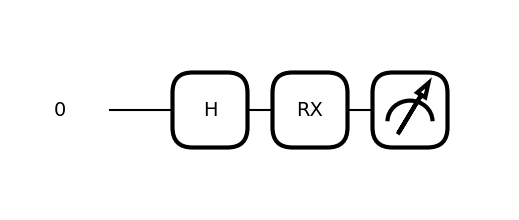

In [9]:
@qml.qnode(dev1)
def prog8(theta):
    qml.Hadamard(wires=0)
    qml.RX(theta, wires=0)
    return qml.state()

angles8 = {"pi/6": np.pi/6, "pi/4": np.pi/4, "pi/3": np.pi/3}
for label, theta in angles8.items():
    s = prog8(theta)
    print(f"H then RX({label}): final state = {s}")

print(qml.draw(prog8)(np.pi/4))
qml.draw_mpl(prog8)(np.pi/4)
plt.show()

### Program 9
Construct a two-qubit quantum circuit by applying the Rotation-X (Rx) gate to the first qubit and the Rotation-Y (Ry) gate to the second qubit. Display the resulting quantum state and visualize the circuit.

Rx(pi/4) on q0, Ry(pi/3) on q1 -> state = [0.8001+0.j     0.4619+0.j     0.    -0.3314j 0.    -0.1913j]
0: ──RX(0.79)─┤  State
1: ──RY(1.05)─┤  State


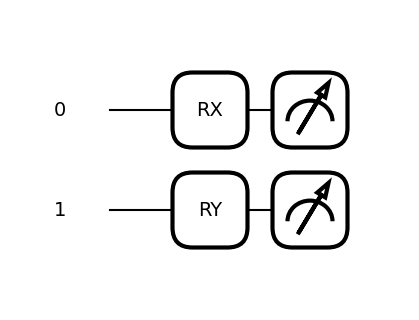

In [10]:
@qml.qnode(dev2)
def prog9(tx, ty):
    qml.RX(tx, wires=0)
    qml.RY(ty, wires=1)
    return qml.state()

tx, ty = np.pi/4, np.pi/3
state = prog9(tx, ty)
print(f"Rx(pi/4) on q0, Ry(pi/3) on q1 -> state = {np.round(state,4)}")
print(qml.draw(prog9)(tx, ty))
qml.draw_mpl(prog9)(tx, ty)
plt.show()

### Program 10
Design a two-qubit quantum circuit by applying the Rotation-Y (Ry) gate, followed by a CNOT gate, and then the Rotation-Z (Rz) gate. Display the resulting quantum state and visualize the entangled quantum circuit.

Ry(pi/3) on q0 -> CNOT(q0,q1) -> Rz(pi/4) on q1 -> state = [0.8001-0.3314j 0.    +0.j     0.    +0.j     0.4619+0.1913j]
Probabilities |00>,|01>,|10>,|11> = [0.75 0.   0.   0.25]
0: ──RY(1.05)─╭●───────────┤  State
1: ───────────╰X──RZ(0.79)─┤  State


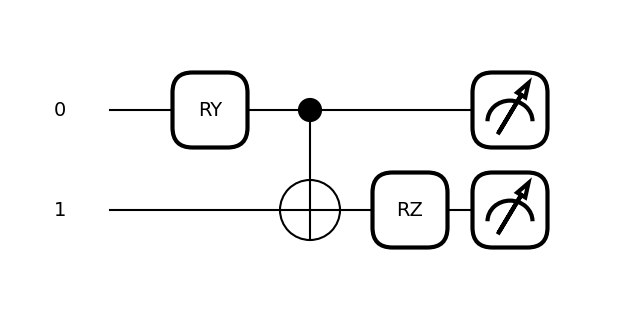


Observation: The CNOT entangles the two qubits so the final state cannot be written as a simple product of two single-qubit states.


In [11]:
@qml.qnode(dev2)
def prog10(ty, tz):
    qml.RY(ty, wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RZ(tz, wires=1)
    return qml.state()

ty, tz = np.pi/3, np.pi/4
state = prog10(ty, tz)
print(f"Ry(pi/3) on q0 -> CNOT(q0,q1) -> Rz(pi/4) on q1 -> state = {np.round(state,4)}")
probs = np.abs(state)**2
print(f"Probabilities |00>,|01>,|10>,|11> = {np.round(probs,4)}")
print(qml.draw(prog10)(ty, tz))
qml.draw_mpl(prog10)(ty, tz)
plt.show()

print("\nObservation: The CNOT entangles the two qubits so the final state cannot be written as a simple "
      "product of two single-qubit states.")

### Program 11
Implement a two-qubit Variational Quantum Circuit (VQC) using multiple Rotation-X (Rx), Rotation-Y (Ry), and Rotation-Z (Rz) gates followed by a CNOT gate. Display the final quantum state and visualize the complete parameterized quantum circuit.

Parameters (radians) = [0.7854 1.0472 1.5708 0.5236 0.6283 0.3927]
Final VQC state = [0.5992-0.4652j 0.16  -0.2751j 0.2081-0.0713j 0.5235+0.0281j]
Probabilities = [0.5755 0.1013 0.0484 0.2748]
0: ──RX(0.79)──RY(1.05)──RZ(1.57)─╭●─┤  State
1: ──RX(0.52)──RY(0.63)──RZ(0.39)─╰X─┤  State


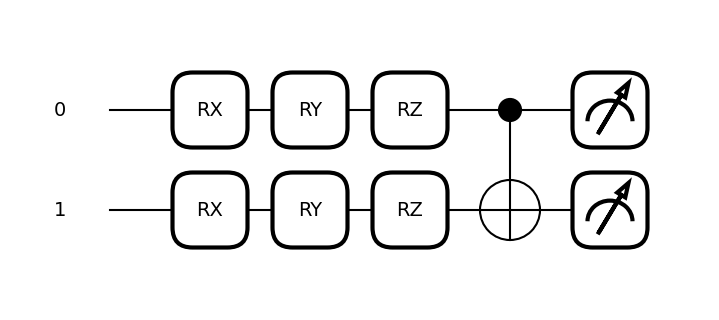


Observation: This two-qubit VQC applies independent Rx-Ry-Rz rotations on each qubit followed by a CNOT, producing a fully parameterized entangling ansatz used as a building block in variational quantum algorithms and quantum machine learning.


In [12]:
@qml.qnode(dev2)
def prog11(params):
    qml.RX(params[0], wires=0)
    qml.RY(params[1], wires=0)
    qml.RZ(params[2], wires=0)
    qml.RX(params[3], wires=1)
    qml.RY(params[4], wires=1)
    qml.RZ(params[5], wires=1)
    qml.CNOT(wires=[0, 1])
    return qml.state()

params = np.array([np.pi/4, np.pi/3, np.pi/2, np.pi/6, np.pi/5, np.pi/8])
state = prog11(params)
print(f"Parameters (radians) = {np.round(params,4)}")
print(f"Final VQC state = {np.round(state,4)}")
print(f"Probabilities = {np.round(np.abs(state)**2,4)}")
print(qml.draw(prog11)(params))
qml.draw_mpl(prog11)(params)
plt.show()

print("\nObservation: This two-qubit VQC applies independent Rx-Ry-Rz rotations on each qubit followed by a "
      "CNOT, producing a fully parameterized entangling ansatz used as a building block in variational "
      "quantum algorithms and quantum machine learning.")

## Result

Parameterized single-qubit rotation gates (Rx, Ry, Rz) were successfully implemented and simulated using
PennyLane. Their individual and combined effects on quantum state evolution, measurement probabilities, and
expectation values were studied and visualized, including a full sweep of the Ry rotation angle against the
⟨Z⟩ expectation value. Two-qubit circuits combining rotation gates with a CNOT gate were also constructed to
demonstrate entanglement, culminating in a fully parameterized two-qubit Variational Quantum Circuit (VQC).
Thus, the study of parameterized rotation gates using PennyLane was carried out and verified successfully.